# Error Analysis — `track_b_modernbert` (Phase 4, Steps 4.4–4.6)

Phase 4's quantitative comparison over `results/unified_predictions.parquet` established
`track_b_modernbert` (token-level ModernBERT fine-tune, ADR-013/ADR-014) as the
best-performing system at **F1 0.7619** (precision 0.7873, recall 0.7381, n=2700).
This notebook digs into *where* and *how* it fails:

1. **Confusion matrix** — the response-level breakdown behind the headline numbers.
2. **Error categorization** — accuracy by task type, false negatives by context length,
   and whether the model is "paranoid" (over-flags) or "overconfident" (under-flags).
3. **Qualitative examples** — five real test-set cases with full context/response text.
4. **Threshold sensitivity (Step 4.5)** — the precision/recall trade-off along `y_score`
   and what it means for a production RAG system (block vs. warn).
5. **Conclusions (Step 4.6)**.

For Track B, `y_score` is the max per-token P(hallucinated) over the response and
`y_pred = 1` iff any token crosses 0.5 — so `y_pred ≡ (y_score >= 0.5)` (asserted in §4).

In [1]:
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.metrics import precision_recall_fscore_support

# Run everything from the repo root so src imports and relative data paths work,
# whether the notebook is executed from notebooks/ or the root.
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.metrics import load_predictions, metrics_for_system, system_predictions  # noqa: E402

SYSTEM = "track_b_modernbert"

unified = load_predictions()
trackb = system_predictions(unified, SYSTEM).sort_values("row_index").reset_index(drop=True)
assert len(trackb) == 2700, f"expected 2700 test rows, got {len(trackb)}"
assert (trackb["row_index"].to_numpy() == np.arange(2700)).all(), "row_index not contiguous"
print(f"{SYSTEM}: {len(trackb)} test rows loaded from results/unified_predictions.parquet")

track_b_modernbert: 2700 test rows loaded from results/unified_predictions.parquet


In [2]:
# Chart styling: same surface/ink/palette conventions as notebooks/01_eda_ragtruth.ipynb
# and scripts/generate_evaluation_plots.py (track_b's fixed hue is #008300).
CHART_SURFACE = "#fcfcfb"
PRIMARY_INK = "#0b0b0b"
SECONDARY_INK = "#52514e"
MUTED_INK = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
TASK_TYPE_COLORS = {"Summary": "#2a78d6", "QA": "#1baf7a", "Data2txt": "#eda100"}

plt.rcParams.update(
    {
        "figure.facecolor": CHART_SURFACE,
        "axes.facecolor": CHART_SURFACE,
        "axes.edgecolor": BASELINE,
        "text.color": PRIMARY_INK,
        "axes.labelcolor": SECONDARY_INK,
        "xtick.color": MUTED_INK,
        "ytick.color": MUTED_INK,
        "font.family": "sans-serif",
    }
)


def style_axes(ax):
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.yaxis.grid(True, color=GRIDLINE, linewidth=1)
    ax.set_axisbelow(True)
    ax.tick_params(left=False)

## 1. Rebuilding test-set metadata (join back to raw text)

`unified_predictions.parquet` stores only ids, labels, and scores — no text and no
context length. Both come from the raw RAGTruth files via the same deterministic
pipeline every system used: `load_merged_dataframe()` → `split == "test"` →
`reset_index(drop=True)`. The positional index of that slice **is** the unified
table's `row_index` (the oversized-response filter dropped zero test rows, verified
by the asserts below), which recovers per-row `context`, `response`, generator
`model`, and the gold hallucination spans (`labels`, with char offsets and
`label_type`).

In [3]:
from src.data.preprocess import load_merged_dataframe

merged_df = load_merged_dataframe()
test_meta = merged_df[merged_df["split"] == "test"].reset_index(drop=True)

# Alignment guards: positional index of the raw test slice == unified row_index.
assert len(test_meta) == len(trackb) == 2700
assert (test_meta["source_id"].to_numpy() == trackb["source_id"].to_numpy()).all()
assert (test_meta["task_type"].to_numpy() == trackb["task_type"].to_numpy()).all()
print("Alignment asserts passed: raw test slice matches unified row_index order.")

analysis = pd.concat(
    [
        trackb[["row_index", "source_id", "task_type", "y_true", "y_pred", "y_score"]],
        test_meta[["model", "context", "response", "labels"]],
    ],
    axis=1,
)

conditions = {
    "TP": (analysis["y_true"] == 1) & (analysis["y_pred"] == 1),
    "FN": (analysis["y_true"] == 1) & (analysis["y_pred"] == 0),
    "FP": (analysis["y_true"] == 0) & (analysis["y_pred"] == 1),
    "TN": (analysis["y_true"] == 0) & (analysis["y_pred"] == 0),
}
analysis["error_type"] = np.select(list(conditions.values()), list(conditions.keys()), default="?")
assert not (analysis["error_type"] == "?").any()
analysis["error_type"].value_counts()

Alignment asserts passed: raw test slice matches unified row_index order.


error_type
TN    1569
TP     696
FN     247
FP     188
Name: count, dtype: int64

In [4]:
import transformers
from transformers import AutoTokenizer

transformers.logging.set_verbosity_error()
warnings.filterwarnings("ignore", message=".*byte fallback.*")  # sentencepiece conversion notice

# ctx_len: same definition as the EDA in notebooks/01_eda_ragtruth.ipynb (DeBERTa token
# count of the raw context). Only 450 unique test contexts (6 responses each), so
# tokenize once per source_id and map.
tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-v3-base")
unique_contexts = analysis.drop_duplicates("source_id").set_index("source_id")["context"]
ctx_len_by_source = unique_contexts.apply(lambda text: len(tokenizer.encode(text, add_special_tokens=True)))
analysis["ctx_len"] = analysis["source_id"].map(ctx_len_by_source)

# seq_len: the sequence length Track B's ModernBERT actually saw per row, free from
# data/processed/token_level_binary_test.parquet (same row order, asserted).
token_test = pd.read_parquet("data/processed/token_level_binary_test.parquet")
assert (token_test["source_id"].to_numpy() == analysis["source_id"].to_numpy()).all()
analysis["seq_len"] = token_test["input_ids"].apply(len).to_numpy()

analysis[["ctx_len", "seq_len"]].describe().round(1)

,ctx_len,seq_len
count,2700.0,2700.0
mean,584.1,788.3
std,325.5,378.4
min,160.0,196.0
25%,342.0,493.8
50%,511.5,713.0
75%,759.0,1020.0
max,1949.0,2388.0


## 2. Confusion matrix (Step 4.4)

Same numbers as the committed `results/confusion_matrix_track_b_modernbert.png`,
reproduced inline for the narrative.

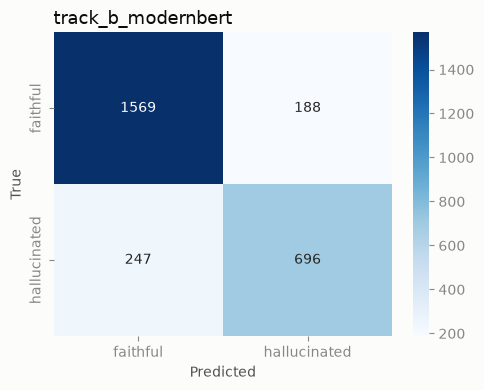

n=2700  precision=0.7873  recall=0.7381  f1=0.7619


In [5]:
overall = metrics_for_system(unified, SYSTEM)
cm = np.array(overall["confusion_matrix"])
assert cm.tolist() == [[1569, 188], [247, 696]], "confusion matrix drifted from committed results"
assert round(overall["f1"], 4) == 0.7619, f"F1 drifted: {overall['f1']}"

CLASS_LABELS = ["faithful", "hallucinated"]
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(SYSTEM, color=PRIMARY_INK, fontsize=13, loc="left")
fig.tight_layout()
plt.show()

print(
    f"n={overall['n']}  precision={overall['precision']:.4f}  "
    f"recall={overall['recall']:.4f}  f1={overall['f1']:.4f}"
)

Of 2700 test responses (943 hallucinated, 1757 faithful), the model gets 2265 right
(**accuracy 83.9%**). The two error cells are asymmetric: it misses **247** hallucinated
responses (FN) while raising **188** false alarms (FP). Precision (0.787) exceeds recall
(0.738) — the model errs toward *trusting* responses, quantified in §3.4.

## 3. Error categorization (Step 4.4)

### 3.1 By task type

In [6]:
def binary_metrics(group):
    precision, recall, f1, _ = precision_recall_fscore_support(
        group["y_true"], group["y_pred"], average="binary", pos_label=1, zero_division=0
    )
    return pd.Series(
        {
            "n": len(group),
            "halluc_rate": group["y_true"].mean(),
            "accuracy": (group["y_true"] == group["y_pred"]).mean(),
            "error_rate": (group["y_true"] != group["y_pred"]).mean(),
            "precision": precision,
            "recall": recall,
            "f1": f1,
        }
    )


by_task = analysis.groupby("task_type").apply(binary_metrics, include_groups=False)
assert int(by_task["n"].sum()) == 2700, "per-task counts must sum to the full test set"
by_task.loc["ALL"] = binary_metrics(analysis)
by_task.round(4)

,n,halluc_rate,accuracy,error_rate,precision,recall,f1
task_type,,,,,,,
Data2txt,900.0,0.6433,0.8333,0.1667,0.8796,0.8584,0.8689
QA,900.0,0.1778,0.8711,0.1289,0.6250,0.6875,0.6548
Summary,900.0,0.2267,0.8122,0.1878,0.6224,0.4363,0.5130
ALL,2700.0,0.3493,0.8389,0.1611,0.7873,0.7381,0.7619


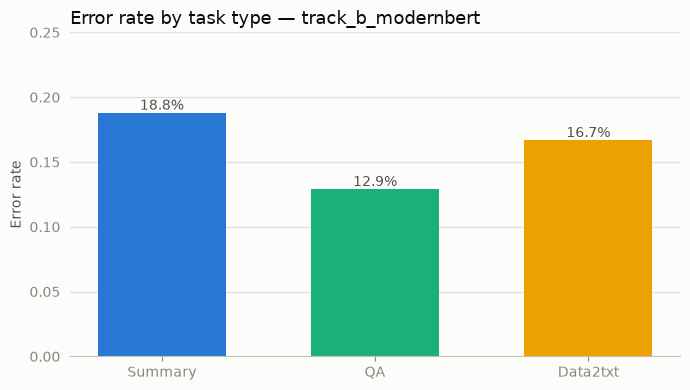

In [7]:
task_order = ["Summary", "QA", "Data2txt"]
error_rates = by_task.loc[task_order, "error_rate"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(task_order, error_rates.values, color=[TASK_TYPE_COLORS[t] for t in task_order], width=0.6)
style_axes(ax)
ax.set_title("Error rate by task type — track_b_modernbert", color=PRIMARY_INK, fontsize=13, loc="left")
ax.set_ylabel("Error rate")
ax.set_ylim(0, 0.25)
for bar, value in zip(bars, error_rates.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1%}",
        ha="center",
        va="bottom",
        color=SECONDARY_INK,
        fontsize=10,
    )
fig.tight_layout()
plt.show()

The headline F1 hides a large task gap:

- **Data2txt is the strong suit** (F1 0.869, precision 0.880, recall 0.858). Its
  hallucinations are frequent (64% base rate) and formulaic — invented attribute values
  that contradict the structured JSON context — which a token-level model learns well.
- **QA sits in the middle** (F1 0.655).
- **Summary is the weak spot** (F1 0.513) and the failure is *recall*: **0.436** — the
  model misses more than half of all hallucinated summaries, even though its raw error
  rate (18.8%) looks only slightly worse than the others. Summary hallucinations are
  paraphrase-level distortions of a long source article, much harder to pin to specific
  tokens than a fabricated fact.

### 3.2 By generator model (supplementary)

In [8]:
by_model = analysis.groupby("model").apply(binary_metrics, include_groups=False)
by_model.round(4)

,n,halluc_rate,accuracy,error_rate,precision,recall,f1
model,,,,,,,
gpt-3.5-turbo-0613,450.0,0.1022,0.8933,0.1067,0.4783,0.4783,0.4783
gpt-4-0613,450.0,0.0933,0.8933,0.1067,0.4483,0.6190,0.5200
llama-2-13b-chat,450.0,0.4600,0.8311,0.1689,0.8164,0.8164,0.8164
llama-2-70b-chat,450.0,0.3800,0.8222,0.1778,0.7630,0.7719,0.7674
llama-2-7b-chat,450.0,0.5022,0.7556,0.2444,0.8053,0.6770,0.7356
mistral-7B-instruct,450.0,0.5578,0.8378,0.1622,0.9238,0.7729,0.8416


Detection quality tracks the *generator's* hallucination base rate: responses from
`gpt-4-0613` / `gpt-3.5-turbo-0613` hallucinate rarely (~9–10%) and their rarer
hallucinations are subtler, so F1 collapses to ≈0.48–0.52 there, while
`mistral-7B-instruct` (56% base rate) reaches F1 0.842. A production deployment
guarding a strong generator faces the *hard* row of this table, not the average.

### 3.3 False negatives by context length

In [9]:
analysis["ctx_bin"] = pd.qcut(analysis["ctx_len"], 4)
positives = analysis[analysis["y_true"] == 1]
negatives = analysis[analysis["y_true"] == 0]

fn_by_bin = positives.groupby("ctx_bin", observed=True).apply(
    lambda g: pd.Series({"n_pos": len(g), "fn_rate": (g["y_pred"] == 0).mean()}), include_groups=False
)
fp_by_bin = negatives.groupby("ctx_bin", observed=True).apply(
    lambda g: pd.Series({"n_neg": len(g), "fp_rate": (g["y_pred"] == 1).mean()}), include_groups=False
)
ctx_table = fn_by_bin.join(fp_by_bin)
task_mix = pd.crosstab(analysis["ctx_bin"], analysis["task_type"], normalize="index")

print("FN/FP rate by context-length quartile (DeBERTa tokens, EDA definition):")
display(ctx_table.round(4))
print("Task-type mix of each quartile (row-normalized) — the confounder:")
display(task_mix.round(3))

FN/FP rate by context-length quartile (DeBERTa tokens, EDA definition):


,n_pos,fn_rate,n_neg,fp_rate
ctx_bin,,,,
"(159.999, 342.0]",131.0,0.3282,553.0,0.1049
"(342.0, 511.5]",126.0,0.4683,540.0,0.0648
"(511.5, 759.0]",363.0,0.1653,321.0,0.1682
"(759.0, 1949.0]",323.0,0.2632,343.0,0.1195


Task-type mix of each quartile (row-normalized) — the confounder:


task_type,Data2txt,QA,Summary
ctx_bin,,,
"(159.999, 342.0]",0.000,0.842,0.158
"(342.0, 511.5]",0.036,0.459,0.505
"(511.5, 759.0]",0.737,0.026,0.237
"(759.0, 1949.0]",0.559,0.000,0.441


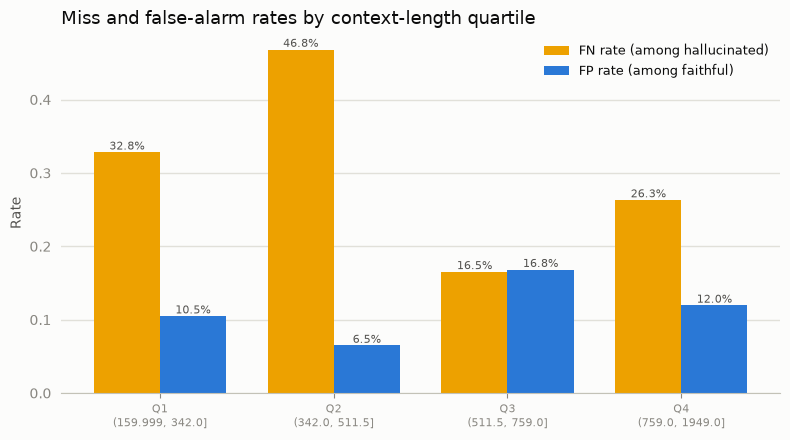

In [10]:
bin_labels = [f"Q{i + 1}\n{interval}" for i, interval in enumerate(ctx_table.index.astype(str))]
x = np.arange(len(bin_labels))
width = 0.38

fig, ax = plt.subplots(figsize=(8, 4.5))
bars_fn = ax.bar(x - width / 2, ctx_table["fn_rate"], width, color="#eda100", label="FN rate (among hallucinated)")
bars_fp = ax.bar(x + width / 2, ctx_table["fp_rate"], width, color="#2a78d6", label="FP rate (among faithful)")
style_axes(ax)
ax.set_title("Miss and false-alarm rates by context-length quartile", color=PRIMARY_INK, fontsize=13, loc="left")
ax.set_ylabel("Rate")
ax.set_xticks(x, bin_labels, fontsize=8)
ax.legend(frameon=False, fontsize=9)
for bars in (bars_fn, bars_fp):
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{bar.get_height():.1%}",
            ha="center",
            va="bottom",
            color=SECONDARY_INK,
            fontsize=8,
        )
fig.tight_layout()
plt.show()

In [11]:
# The quartile pattern is confounded by task type (each quartile is dominated by a
# different task) — check the length effect *within* task instead.
fn_within_task = positives.groupby(
    ["task_type", pd.qcut(positives["ctx_len"], 3)], observed=True
).apply(lambda g: pd.Series({"n_pos": len(g), "fn_rate": (g["y_pred"] == 0).mean()}), include_groups=False)
display(fn_within_task.round(3))

max_seq = int(analysis["seq_len"].max())
print(
    f"Model-visible sequence length: max {max_seq} tokens vs the 4096-token budget "
    f"Track B trained/ran with — no test row was truncated, so window overflow "
    f"cannot explain any false negative."
)

n_pos  fn_rate
task_type ctx_len                         
Data2txt  (159.999, 580.0]   46.0    0.109
          (580.0, 763.0]    299.0    0.140
          (763.0, 1949.0]   234.0    0.150
QA        (159.999, 580.0]  160.0    0.312
Summary   (159.999, 580.0]  109.0    0.550
          (580.0, 763.0]     15.0    0.400
          (763.0, 1949.0]    80.0    0.612

Model-visible sequence length: max 2388 tokens vs the 4096-token budget Track B trained/ran with — no test row was truncated, so window overflow cannot explain any false negative.


The raw quartile pattern (FN rate 32.8% → 46.8% → 16.5% → 26.3%) is **not** a
context-length effect — it is task mix in disguise. Q1 is 84% QA, Q2 is 51% Summary
(the low-recall task, hence the 46.8% spike), Q3 is 74% Data2txt (the easy task, hence
the dip). Within task, length has at most a mild effect (Data2txt FN rate drifts
10.9% → 15.0% across terciles; Summary is bad at *every* length, 40–61%). And since the
longest model-visible sequence is 2388 tokens against a 4096 budget, truncation is
ruled out entirely. **Conclusion: task type, not context length, is the real error
axis.**

### 3.4 Paranoid or overconfident?

In [12]:
fp_count = int((analysis["error_type"] == "FP").sum())
fn_count = int((analysis["error_type"] == "FN").sum())
print(f"False negatives: {fn_count}  -> misses {fn_count / len(positives):.1%} of {len(positives)} hallucinated responses")
print(f"False positives: {fp_count}  -> flags  {fp_count / len(negatives):.1%} of {len(negatives)} faithful responses")
print(f"FP:FN ratio = {fp_count / fn_count:.2f}")

pd.crosstab(analysis["task_type"], analysis["error_type"], margins=True)

False negatives: 247  -> misses 26.2% of 943 hallucinated responses
False positives: 188  -> flags  10.7% of 1757 faithful responses
FP:FN ratio = 0.76


error_type,FN,FP,TN,TP,All
task_type,,,,,
Data2txt,82,68,253,497,900
QA,50,66,674,110,900
Summary,115,54,642,89,900
All,247,188,1569,696,2700


**Verdict: overconfident, not paranoid.** The model misses 26.2% of hallucinated
responses but false-alarms on only 10.7% of faithful ones (FP:FN = 0.76). At its
default operating point it errs toward trusting the generator. Mechanically this makes
sense for a token-level detector: to flag a response, at least one token must cross
P(hallucinated) ≥ 0.5, so diffuse, low-confidence suspicion spread across many tokens
never triggers — a bias toward silence. The imbalance is worst on Summary (115 FN vs
54 FP); only on QA do false alarms outnumber misses (66 FP vs 50 FN).

## 4. Qualitative examples (Step 4.4)

Five real test rows, selected by rule (not cherry-picked): the highest-scored true
positive, the lowest-scored false negative *with a purely-subtle gold annotation*, the
highest-scored false positive, the row closest to the 0.5 decision boundary, and the
lowest-scored true negative. Gold hallucinated spans are marked `**[[...]]**` inside
the response using RAGTruth's char offsets. Output is Markdown, ready to paste into
the README.

In [13]:
def highlight_spans(response: str, spans) -> str:
    """Wrap gold hallucinated spans in **[[...]]** markers using char offsets."""
    parts, cursor = [], 0
    for span in sorted(spans, key=lambda span: span["start"]):
        parts.append(response[cursor : span["start"]])
        parts.append(f"**[[{response[span['start'] : span['end']]}]]**")
        cursor = span["end"]
    parts.append(response[cursor:])
    return "".join(parts)


def as_blockquote(text: str) -> str:
    return "\n".join("> " + line for line in text.splitlines())


def show_example(row, title: str, max_context_chars: int = 1200) -> None:
    context = row["context"]
    if len(context) > max_context_chars:
        context = context[:max_context_chars].rstrip() + " [...]"
    response = highlight_spans(row["response"], row["labels"])
    span_types = ", ".join(sorted({span["label_type"] for span in row["labels"]})) or "none (faithful)"
    display(
        Markdown(
            f"### {title}\n"
            f"**Task:** {row['task_type']} · **Generator:** {row['model']} · "
            f"**y_true:** {row['y_true']} · **y_pred:** {row['y_pred']} · **y_score:** {row['y_score']:.4f}\n\n"
            f"**Gold annotation:** {span_types}\n\n"
            f"**Context (excerpt):**\n{as_blockquote(context)}\n\n"
            f"**Response** (gold hallucinated spans marked `**[[...]]**`):\n{as_blockquote(response)}"
        )
    )


true_positives = analysis[analysis["error_type"] == "TP"].sort_values("y_score", ascending=False)
false_negatives = analysis[analysis["error_type"] == "FN"].sort_values("y_score")
false_positives = analysis[analysis["error_type"] == "FP"].sort_values("y_score", ascending=False)
true_negatives = analysis[analysis["error_type"] == "TN"].sort_values("y_score")

subtle_fns = false_negatives[
    false_negatives["labels"].apply(lambda spans: all("Subtle" in span["label_type"] for span in spans))
]
example_tp = true_positives.iloc[0]
example_fn = subtle_fns.iloc[0]
example_fp = false_positives.iloc[0]
example_borderline = analysis.loc[(analysis["y_score"] - 0.5).abs().idxmin()]
example_tn = true_negatives.iloc[0]

selection = pd.DataFrame(
    [example_tp, example_fn, example_fp, example_borderline, example_tn],
    index=["TP", "FN (subtle)", "FP", "borderline", "TN"],
)[["row_index", "source_id", "task_type", "model", "y_true", "y_pred", "y_score", "error_type"]]
selection

,row_index,source_id,task_type,model,y_true,y_pred,y_score,error_type
TP,2399,15513,QA,llama-2-70b-chat,1,1,9.999961e-01,TP
FN (subtle),1470,14548,Data2txt,gpt-4-0613,1,0,3.774517e-03,FN
FP,2146,15254,QA,llama-2-13b-chat,0,1,9.999913e-01,FP
borderline,1781,15019,Data2txt,llama-2-70b-chat,0,0,4.999938e-01,TN
TN,2180,15300,QA,mistral-7B-instruct,0,0,5.441233e-07,TN


In [14]:
show_example(example_tp, "Example 1 — True positive: hallucination caught with full confidence")

### Example 1 — True positive: hallucination caught with full confidence
**Task:** QA · **Generator:** llama-2-70b-chat · **y_true:** 1 · **y_pred:** 1 · **y_score:** 1.0000

**Gold annotation:** Evident Baseless Info, Subtle Baseless Info

**Context (excerpt):**
> Question: how to plan a trip to germany
> 
> Passages: passage 1:Share. Budget Germany: Travel to Germany on a budget with our budget travel tips. Get discounts and save money in Germany, from bargain flights to Germany, and cheap hotels and hostels in Germany, to restaurants, public transportation, and sightseeing in German cities.efore you go to Germany, check out these helpful Germany travel tips, from visa requirements, when and where to go in Germany, what to see in Germany, to getting around in Germany and budget travel tips.
> 
> passage 2:Plan ahead: We have helpful tips to plan you Germany travels with your pet. Read about air travel with pets, vaccinations for pets, and pet-friendly hotels in Germany. Learn the rules for pets on German trains, and get helpful Germany travel tips for your cats and dogs.efore you go to Germany, check out these helpful Germany travel tips, from visa requirements, when and where to go in Germany, what to see in Germany, to getting around in Germany and budget travel tips.
> 
> passage 3:Every country and every culture offers a unique opportunity—and sometimes a challenge—to enlarge one’s personal experience and understanding of the world. Germany is no e [...]

**Response** (gold hallucinated spans marked `**[[...]]**`):
> Sure, I can help you with that! Based on the given passages, here are some tips for planning a trip to Germany:
> 
> 1. Plan ahead: Research and book your flights, accommodation, and transportation in advance to get the best deals.
> 2. Consider budget options: Look for budget-friendly flights, hotels, and hostels, and use public transportation to get around.
> 3. Bring your pet: If you're planning to bring your furry friend along, research pet-friendly hotels and train routes in advance.
> 4. Learn about German culture: Take some time to learn about German customs, traditions, and way of life to enhance your travel experience.
> 5. Check visa requirements: Make sure you have the necessary documents and visas required for entry into Germany, if applicable.
> **[[6. Pack appropriately: Germany can get quite chilly, especially in the winter months, so pack warm clothing and comfortable shoes for sightseeing.
> 7. Use travel apps: Utilize travel apps like Google Maps or Rome2rio to plan your itinerary and navigate through German cities.]]**
> 8. Learn some basic German phrases: While many Germans speak English fluently, it's always appreciated when visitors make an effort to speak the local language. **[[Learning basic phrases like "hello" (Hallo), "thank you" (Danke), and "excuse me" (Entschuldigung)]]** can go a long way in making your interactions with locals more enjoyable.
> 
> I hope these tips help you plan your trip to Germany!

In [15]:
show_example(example_fn, "Example 2 — False negative: subtle hallucination missed (y_score 0.004)")

### Example 2 — False negative: subtle hallucination missed (y_score 0.004)
**Task:** Data2txt · **Generator:** gpt-4-0613 · **y_true:** 1 · **y_pred:** 0 · **y_score:** 0.0038

**Gold annotation:** Subtle Baseless Info

**Context (excerpt):**
> {
>   "name": "Radio Prophets",
>   "address": "",
>   "city": "Santa Barbara",
>   "state": "CA",
>   "categories": "Arts & Entertainment, Jazz & Blues, Local Services, Nightlife, Party & Event Planning, Musicians, Musical Instrument Services, Music Venues, Wedding Planning, Professional Services, Event Planning & Services, Music Production Services",
>   "hours": {
>     "Monday": "8:0-2:0",
>     "Tuesday": "8:0-2:0",
>     "Wednesday": "8:0-2:0",
>     "Thursday": "8:0-2:0",
>     "Friday": "8:0-2:0",
>     "Saturday": "8:0-2:0",
>     "Sunday": "8:0-2:0"
>   },
>   "attributes": {
>     "BusinessParking": {
>       "garage": false,
>       "street": true,
>       "validated": false,
>       "lot": false,
>       "valet": false
>     },
>     "RestaurantsReservations": null,
>     "OutdoorSeating": true,
>     "WiFi": "free",
>     "RestaurantsTakeOut": null,
>     "RestaurantsGoodForGroups": null,
>     "Music": true,
>     "Ambience": null
>   },
>   "business_stars": 5.0,
>   "review_info": [
>     {
>       "review_stars": 5.0,
>       "review_date": "2021-09-21 05:09:33",
>       "review_text": "Imagine having your close friends with incredible musical talent be your wedding band -- that is what hiring the Radio Prophets to play at your weddin [...]

**Response** (gold hallucinated spans marked `**[[...]]**`):
> Radio Prophets is a **[[well-regarded local business]]** based in Santa Barbara, CA that offers a wide range of services such as music performances, event planning, and wedding planning. The business is open daily from 8:00 to 2:00 and provides free Wi-Fi for its patrons. It has received a perfect 5-star rating from its clients who have praised the band's musical talent, professionalism, and ability to set the tone of various events. Customers have specifically highlighted the band's versatility, with performances ranging from piano acoustics, jazz music, to dance sets. The band also takes pride in their efficient communication, easy planning, and their **[[ability to make memorable events for their clients]]**. Street parking is available and the venue also offers outdoor seating.

In [16]:
show_example(example_fp, "Example 3 — False positive: faithful response flagged with full confidence")

### Example 3 — False positive: faithful response flagged with full confidence
**Task:** QA · **Generator:** llama-2-13b-chat · **y_true:** 0 · **y_pred:** 1 · **y_score:** 1.0000

**Gold annotation:** none (faithful)

**Context (excerpt):**
> Question: difference between an adverb clause and an adjective clause
> 
> Passages: passage 1:An adverb clause is a dependent clause that modifies a verb, adjective or another adverb. It usually modifies the verb. Adverb clauses are introduced by subordinate conjunctions including after, although, as, as if, before, because, if, since, so that, than, though, unless, until, when, where, and while.
> 
> passage 2:Parts of the Sentence - Adjective, Adverb, and Noun Clauses. The adjective clause is used to modify a noun or a pronoun. It will begin with a relative pronoun (who, whose, whom, which, and that) or a subordinate conjunction (when and where). Those are the only words that can be used to introduce an adjective clause.
> 
> passage 3:Adjective Clauses. Adjective clauses are dependent clauses that modify nouns or pronouns. Much like adverbial clauses, students who are trying to identify adjective clauses should try to determine what kinds of questions the clause in questions answers.
> 

**Response** (gold hallucinated spans marked `**[[...]]**`):
> Sure! Based on the given passages, here's the difference between an adverb clause and an adjective clause:
> 
> An adverb clause modifies a verb, adjective, or another adverb, and it is introduced by subordinate conjunctions such as after, although, as, as if, before, because, if, since, so that, than, though, unless, until, when, where, and while.
> 
> An adjective clause, on the other hand, modifies a noun or pronoun and begins with a relative pronoun (who, whose, whom, which, and that) or a subordinate conjunction (when and where).
> 
> So, the main difference is that adverb clauses modify verbs, adjectives, or other adverbs, while adjective clauses modify nouns or pronouns.
> 
> Here are some examples of each type of clause:
> 
> Adverb clause:
> 
> * Although I studied hard, I failed the exam. (modifying the verb "failed")
> * She walked slowly so that she would not fall. (modifying the verb "walked")
> 
> Adjective clause:
> 
> * The book that is on the table is mine. (modifying the noun "book")
> * He is the man whom I met yesterday. (modifying the noun "man")

In [17]:
show_example(example_borderline, "Example 4 — Borderline: a faithful response at the 0.5 decision boundary")

### Example 4 — Borderline: a faithful response at the 0.5 decision boundary
**Task:** Data2txt · **Generator:** llama-2-70b-chat · **y_true:** 0 · **y_pred:** 0 · **y_score:** 0.5000

**Gold annotation:** none (faithful)

**Context (excerpt):**
> {
>   "name": "El Rincon Bohemio-Goleta",
>   "address": "298 Pine Ave",
>   "city": "Goleta",
>   "state": "CA",
>   "categories": "Mexican, Restaurants",
>   "hours": {
>     "Monday": "11:0-21:0",
>     "Tuesday": "11:0-21:0",
>     "Wednesday": "11:0-21:0",
>     "Thursday": "11:0-21:0",
>     "Friday": "11:0-21:0",
>     "Saturday": "9:0-21:0",
>     "Sunday": "9:0-21:0"
>   },
>   "attributes": {
>     "BusinessParking": {
>       "garage": false,
>       "street": false,
>       "validated": false,
>       "lot": true,
>       "valet": false
>     },
>     "RestaurantsReservations": true,
>     "OutdoorSeating": true,
>     "WiFi": "free",
>     "RestaurantsTakeOut": true,
>     "RestaurantsGoodForGroups": true,
>     "Music": null,
>     "Ambience": {
>       "romantic": false,
>       "intimate": false,
>       "classy": false,
>       "hipster": false,
>       "divey": false,
>       "touristy": false,
>       "trendy": false,
>       "upscale": false,
>       "casual": true
>     }
>   },
>   "business_stars": 3.5,
>   "review_info": [
>     {
>       "review_stars": 2.0,
>       "review_date": "2014-10-26 06:39:06",
>       "review_text": "Five stars? People must be out of their minds (not surprising near UCSB). I heard great things about the \"old Rincon\", b [...]

**Response** (gold hallucinated spans marked `**[[...]]**`):
> El Rincon Bohemio-Goleta is a Mexican restaurant located in Goleta, CA, with a 3.5-star rating based on 3 reviews. The restaurant offers both indoor and outdoor seating, Wi-Fi, and take-out services. The menu includes a variety of traditional Mexican dishes, and the restaurant is known for its delicious steak Bohemio and micheladas. The atmosphere is casual, and the mariachi music played throughout the restaurant adds to the festive ambiance. Some customers have noted that the food quality has decreased recently, but overall, the restaurant remains a popular spot for those looking for authentic Mexican cuisine in the area.

In [18]:
show_example(example_tn, "Example 5 — True negative: an easy faithful case")

### Example 5 — True negative: an easy faithful case
**Task:** QA · **Generator:** mistral-7B-instruct · **y_true:** 0 · **y_pred:** 0 · **y_score:** 0.0000

**Gold annotation:** none (faithful)

**Context (excerpt):**
> Question: avg cost to install a second floor in a house
> 
> Passages: passage 1:1 Hiring a remodeling contractor to build a second floor addition can run $100-$300 a square foot for the typical addition (2-3 bedrooms and a bath plus a flight of stairs), but can go as high as $400-$500 per square foot depending on complexity, quality of materials and local labor rates.uilding a second floor (also called a second story) can added much-needed space, but costs at least 20 percent more than building the same square footage at ground level. However. if you don't have the land to build out it can make sense to go up. Typical costs:
> 
> passage 2:Our free calculator uses recent, trusted data to estimate costs for your Carpet Installation project. For a basic 250 square feet project in zip code 47474, the benchmark cost to Install Carpet ranges between $3.74 - $4.83 per square foot* . To estimate costs for your project:1.Set Project Zip Code Enter the Zip Code for the location where labor is hired and materials purchased.2.ur free calculator uses recent, trusted data to estimate costs for your Carpet Installation project. For a basic 250 square feet project in zip code 47474, the benchmark cost t [...]

**Response** (gold hallucinated spans marked `**[[...]]**`):
> Unable to answer based on given passages.

## 5. Threshold sensitivity (Step 4.5)

`y_score` = max per-token P(hallucinated), so sweeping a threshold over it directly
re-tunes the deployed decision rule. The default `y_pred` is exactly `y_score >= 0.5`
(asserted below), so the 0.5 row must reproduce the official test metrics.

In [19]:
assert ((analysis["y_score"] >= 0.5).astype(int) == analysis["y_pred"]).all(), (
    "track_b y_pred must equal y_score >= 0.5"
)

rows = []
for threshold in [i / 10 for i in range(1, 10)]:
    y_pred_at_t = (analysis["y_score"] >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        analysis["y_true"], y_pred_at_t, average="binary", pos_label=1, zero_division=0
    )
    rows.append(
        {
            "threshold": threshold,
            "flagged": int(y_pred_at_t.sum()),
            "precision": precision,
            "recall": recall,
            "f1": f1,
        }
    )
threshold_table = pd.DataFrame(rows)

row_05 = threshold_table.set_index("threshold").loc[0.5]
assert np.isclose(row_05["precision"], overall["precision"])
assert np.isclose(row_05["recall"], overall["recall"])
assert np.isclose(row_05["f1"], overall["f1"])
print("threshold=0.5 reproduces the official precision/recall/F1 exactly.")
threshold_table.round(4)

threshold=0.5 reproduces the official precision/recall/F1 exactly.


,threshold,flagged,precision,recall,f1
0,0.1,1238,0.6422,0.8431,0.7290
1,0.2,1089,0.6979,0.8059,0.7480
2,0.3,1004,0.7400,0.7879,0.7632
3,0.4,942,0.7611,0.7603,0.7607
4,0.5,884,0.7873,0.7381,0.7619
5,0.6,825,0.8121,0.7105,0.7579
6,0.7,770,0.8442,0.6893,0.7589
7,0.8,714,0.8627,0.6532,0.7435
8,0.9,646,0.8793,0.6023,0.7149


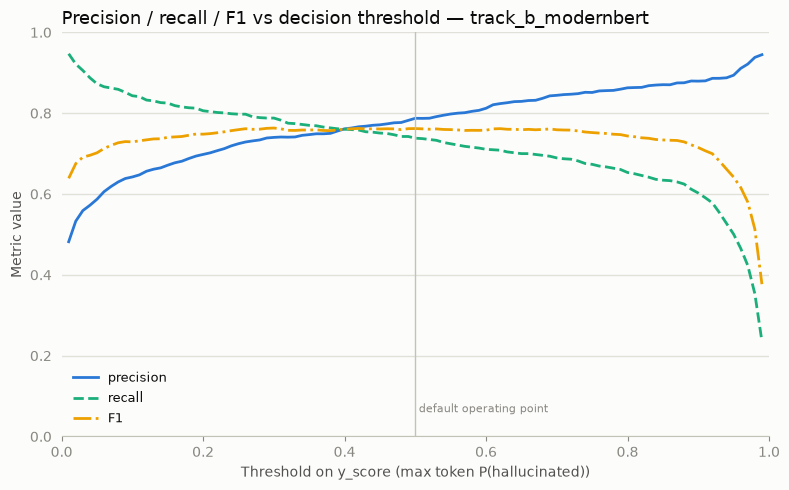

In [20]:
fine_thresholds = np.linspace(0.01, 0.99, 99)
fine = {"precision": [], "recall": [], "f1": []}
for threshold in fine_thresholds:
    y_pred_at_t = (analysis["y_score"] >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        analysis["y_true"], y_pred_at_t, average="binary", pos_label=1, zero_division=0
    )
    fine["precision"].append(precision)
    fine["recall"].append(recall)
    fine["f1"].append(f1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(fine_thresholds, fine["precision"], color="#2a78d6", linestyle="-", linewidth=2, label="precision")
ax.plot(fine_thresholds, fine["recall"], color="#1baf7a", linestyle="--", linewidth=2, label="recall")
ax.plot(fine_thresholds, fine["f1"], color="#eda100", linestyle="-.", linewidth=2, label="F1")
ax.axvline(0.5, color=BASELINE, linewidth=1)
ax.text(0.505, 0.06, "default operating point", color=MUTED_INK, fontsize=8)
style_axes(ax)
ax.set_title("Precision / recall / F1 vs decision threshold — track_b_modernbert", color=PRIMARY_INK, fontsize=13, loc="left")
ax.set_xlabel("Threshold on y_score (max token P(hallucinated))")
ax.set_ylabel("Metric value")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.0)
ax.legend(frameon=False, loc="lower left", fontsize=9)
fig.tight_layout()
plt.show()

**Reading the trade-off for a production RAG system.** F1 sits on a broad plateau
(0.73–0.76 for thresholds 0.2–0.7; the sweep even peaks at 0.763 at t=0.3, marginally
above the default 0.762), so the threshold is effectively a free product knob:

- **Block mode** (auto-reject flagged answers): a false positive destroys a good answer,
  so precision matters most. At **t = 0.9** precision reaches **0.879** while recall
  drops to **0.602** — only ~1 in 8 blocked answers is a mistake, but 4 in 10
  hallucinated answers still get through. Blocking alone is not a safety guarantee.
- **Warn mode** (show a "verify this" banner, keep the answer): a false positive costs
  only mild alert fatigue. At **t = 0.1** recall reaches **0.843** with precision
  **0.642** — the system catches ~5 in 6 hallucinated answers, at the price of ~1 in 3
  warnings being unnecessary.
- A sensible production stack uses **both from the same model**: block above a high
  threshold, warn above a low one, pass below.

Caveat: `y_score` is a *max over token probabilities*, not a calibrated response-level
probability — these thresholds are operating points, not confidence statements, and
they should be re-tuned on validation data (not this test set) before deployment.

## 6. Conclusions (Step 4.6)

1. **The headline F1 (0.762) is an average over very different tasks.** Data2txt is
   close to solved (F1 0.869); Summary is not (F1 0.513, recall 0.436) — the model
   misses more than half of hallucinated summaries. Any claim about this detector must
   be qualified by task type.

2. **The model is overconfident, not paranoid.** It misses 26.2% of hallucinated
   responses but flags only 10.7% of faithful ones (FN 247 vs FP 188). The token-level
   decision rule (flag only if some token crosses 0.5) structurally favors silence over
   alarm — diffuse suspicion never triggers.

3. **Context length is a red herring; truncation is ruled out.** The apparent FN-rate
   swing across length quartiles (16.5%–46.8%) is task mix in disguise; within a task
   the effect is mild (Data2txt 10.9% → 15.0%). No test sequence (max 2388 tokens)
   approaches the 4096-token window.

4. **Subtle hallucinations are missed disproportionately — and the hardest inputs come
   from the best generators.** Positives annotated *only* with "Subtle" span types are
   missed 40.3% of the time vs 27.0% for evident-only ones, and detection F1 drops to
   ≈0.48–0.52 on GPT-3.5/GPT-4 outputs, where hallucinations are rare and subtle. The
   deployment scenario that matters most (a strong generator, occasional subtle
   fabrication) is exactly where the detector is weakest.

5. **The threshold is a product decision, and one model serves both use cases.** F1 is
   flat across thresholds 0.2–0.7, so the same checkpoint supports a high-precision
   block mode (t=0.9: precision 0.879, recall 0.602) and a high-recall warn mode
   (t=0.1: recall 0.843, precision 0.642) — but even at the most aggressive setting,
   ~16% of hallucinations slip through, so the detector is a risk reducer, not a
   guarantee.